In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
########  P1  ########
# PART 1 #


assessments_path = "assessments.csv"
assessments = pd.read_csv(assessments_path)

courses_path = "courses.csv"
courses = pd.read_csv(courses_path)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

In [8]:
assessments = pd.read_csv(assessments_path)
courses = pd.read_csv(courses_path)

print("Assessments shape:", assessments.shape)
print("Courses shape:", courses.shape)

Assessments shape: (13, 6)
Courses shape: (4, 3)


In [9]:
print("Assessments:")
print(assessments)

print("\nCourses:")
print(courses)

Assessments:
    assessment_id month course_id    batch  score  attendance_pct
0               1   Jan        C1  Morning     72              90
1               2   Jan        C2  Evening     45              70
2               3   Jan        C3  Morning     65              85
3               4   Jan        C4  Weekend     38              60
4               5   Feb        C1  Evening     80              95
5               6   Feb        C2  Weekend     55              80
6               7   Feb        C3  Morning     48              75
7               8   Feb        C4  Evening     68              88
8               9   Mar        C1  Weekend     90              98
9              10   Mar        C2  Morning     60              82
10             11   Mar        C3  Evening     75              92
11             12   Mar        C4  Weekend     42              65
12             12   Mar        C4  Weekend     42              65

Courses:
  course_id   course  department
0        C1    Excel

In [10]:
assessments["score"] = pd.to_numeric(
    assessments["score"], errors="raise"
)

assessments["attendance_pct"] = pd.to_numeric(
    assessments["attendance_pct"], errors="raise"
)

print(assessments[["score", "attendance_pct"]].dtypes)

score             int64
attendance_pct    int64
dtype: object


In [11]:
before_rows = len(assessments)

assessments = assessments.drop_duplicates().copy()

after_rows = len(assessments)

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before duplicate removal: 13
Rows after duplicate removal: 12
Duplicates removed: 1


In [12]:
assert len(assessments) == 12, "Expected 12 rows after duplicate removal"

print("Assertion passed: assessments has exactly 12 rows.")

Assertion passed: assessments has exactly 12 rows.


In [13]:
merged = assessments.merge(
    courses,
    on="course_id",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", merged.shape)
display(merged)

Merged shape: (12, 8)


,assessment_id,month,course_id,batch,score,attendance_pct,course,department
0,1,Jan,C1,Morning,72,90,Excel,Business
1,2,Jan,C2,Evening,45,70,PowerBI,Business
2,3,Jan,C3,Morning,65,85,SQL,Technology
3,4,Jan,C4,Weekend,38,60,Python,Technology
4,5,Feb,C1,Evening,80,95,Excel,Business
5,6,Feb,C2,Weekend,55,80,PowerBI,Business
6,7,Feb,C3,Morning,48,75,SQL,Technology
7,8,Feb,C4,Evening,68,88,Python,Technology
8,9,Mar,C1,Weekend,90,98,Excel,Business
9,10,Mar,C2,Morning,60,82,PowerBI,Business


In [14]:
assert len(merged) == 12, "Merged DataFrame should contain exactly 12 rows"

print("Assertion passed: merged DataFrame has exactly 12 rows.")

Assertion passed: merged DataFrame has exactly 12 rows.


In [15]:
unmatched = merged["department"].isna().sum()

print("Unmatched course_id records:", unmatched)

assert unmatched == 0, "Some course_id values were not matched"

Unmatched course_id records: 0


In [16]:
########### P2 ###########

merged["pass_flag"] = (merged["score"] >= 50).astype(int)

display(
    merged[
        ["assessment_id", "score", "pass_flag"]
    ]
)

,assessment_id,score,pass_flag
0,1,72,1
1,2,45,0
2,3,65,1
3,4,38,0
4,5,80,1
5,6,55,1
6,7,48,0
7,8,68,1
8,9,90,1
9,10,60,1


In [17]:
department_summary = (
    merged
    .groupby("department")
    .agg(
        total_assessments=("assessment_id", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)

department_summary["pass_rate_pct"] = (
    department_summary["passing_count"]
    / department_summary["total_assessments"]
    * 100
)

department_summary["pass_rate_pct"] = (
    department_summary["pass_rate_pct"].round(2)
)

display(department_summary)

,department,total_assessments,passing_count,pass_rate_pct
0,Business,6,5,83.33
1,Technology,6,3,50.00


In [18]:
course_summary = (
    merged
    .groupby(["course_id", "course"])
    .agg(
        total_assessments=("assessment_id", "count"),
        passing_count=("pass_flag", "sum")
    )
    .reset_index()
)

course_summary["pass_rate_pct"] = (
    course_summary["passing_count"]
    / course_summary["total_assessments"]
    * 100
)

course_summary["pass_rate_pct"] = (
    course_summary["pass_rate_pct"].round(2)
)

display(course_summary)

,course_id,course,total_assessments,passing_count,pass_rate_pct
0,C1,Excel,3,3,100.00
1,C2,PowerBI,3,2,66.67
2,C3,SQL,3,2,66.67
3,C4,Python,3,1,33.33


In [19]:
lowest_rate = course_summary["pass_rate_pct"].min()

lowest_courses = course_summary[
    course_summary["pass_rate_pct"] == lowest_rate
]

print("Course(s) with the lowest pass rate:")

for _, row in lowest_courses.iterrows():
    print(
        f"Course: {row['course']} ({row['course_id']}) | "
        f"Passing count: {row['passing_count']} | "
        f"Total assessments: {row['total_assessments']} | "
        f"Pass rate: {row['pass_rate_pct']:.2f}%"
    )

Course(s) with the lowest pass rate:
Course: Python (C4) | Passing count: 1 | Total assessments: 3 | Pass rate: 33.33%


In [20]:
######## P3 ########

month_order = ["Jan", "Feb", "Mar"]

monthly_summary = (
    merged
    .groupby("month", observed=False)
    .agg(
        average_score=("score", "mean")
    )
    .reindex(month_order)
    .reset_index()
)

monthly_summary["average_score"] = (
    monthly_summary["average_score"].round(2)
)

display(monthly_summary)

,month,average_score
0,Jan,55.00
1,Feb,62.75
2,Mar,66.75


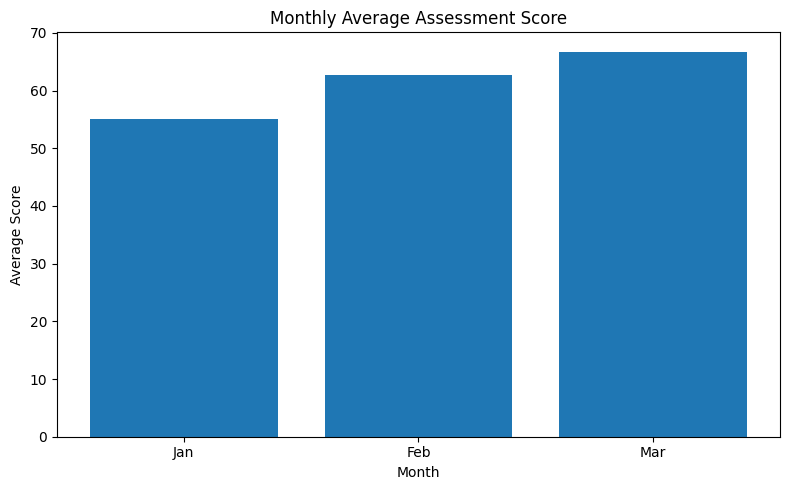

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    monthly_summary["month"],
    monthly_summary["average_score"]
)

plt.title("Monthly Average Assessment Score")
plt.xlabel("Month")
plt.ylabel("Average Score")

plt.tight_layout()

plt.savefig(
    output_dir / "python_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
merged.to_csv(
    output_dir / "clean_data.csv",
    index=False
)

print("Saved:", output_dir / "clean_data.csv")

Saved: outputs\clean_data.csv


In [23]:
department_summary.to_csv(
    output_dir / "python_summary.csv",
    index=False
)

print("Saved:", output_dir / "python_summary.csv")

Saved: outputs\python_summary.csv


In [24]:
print("Output files:")

for file in output_dir.iterdir():
    print("-", file.name)

Output files:
- clean_data.csv
- python_chart.png
- python_summary.csv
